In [35]:
import networkx as nx
import numpy as np
from scipy.spatial import Delaunay
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal, norm
import matplotlib.pyplot as plt
from scipy import stats

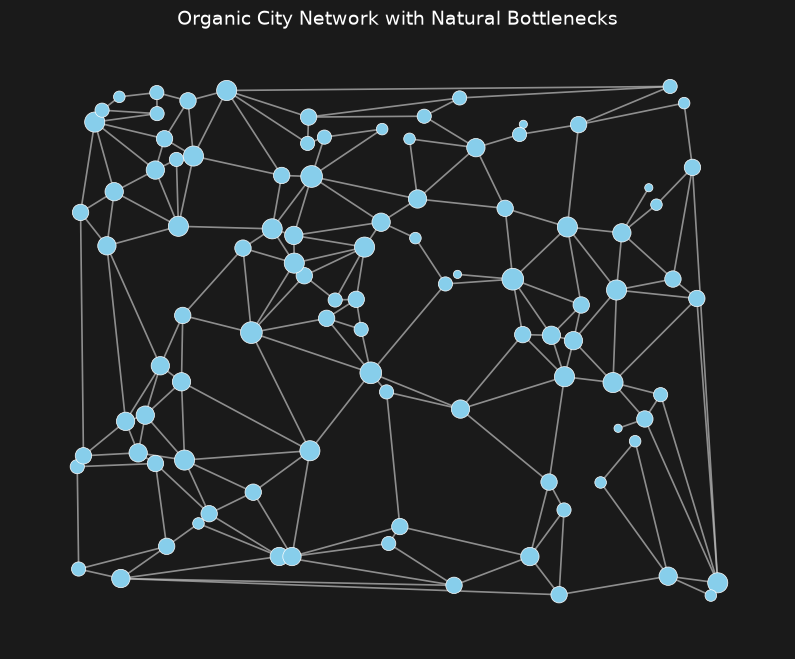

In [36]:
import networkx as nx
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt

N_NODES = 100
points = np.random.rand(N_NODES, 2)
pos = {i: (points[i, 0], points[i, 1]) for i in range(N_NODES)}

tri = Delaunay(points, incremental=True)
G = nx.Graph()
for simplex in tri.simplices:
    G.add_edge(simplex[0], simplex[1])
    G.add_edge(simplex[1], simplex[2])
    G.add_edge(simplex[2], simplex[0])

# ==========================================
# INTRODUCE ORGANIC BOTTLENECKS & CHOKE POINTS
# ==========================================
# Randomly remove ~20% of the edges to create irregular blocks and dead ends
edges_to_remove = [
    (u, v) for u, v in G.edges() if np.random.rand() < 0.25
]
G.remove_edges_from(edges_to_remove)

# Ensure the graph stays fully connected (keeps the main city component)
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    # Re-sync positions for the active nodes
    pos = {n: pos[n] for n in G.nodes()}

# ==========================================
# PRESERVE YOUR EXACT VARIABLE STRUCTURE
# ==========================================
nx.set_node_attributes(G, pos, 'pos')
unique_edges = sorted([tuple(sorted((u, v))) for u, v in G.edges()])
N_EDGES = len(unique_edges)

# Calculate dynamic node sizes based on actual road intersections
node_sizes = [G.degree(n) * 35 for n in G.nodes()]

# Plot the organic city with bottlenecks
plt.figure(figsize=(10, 8))
ax = plt.gca()
ax.set_facecolor('#1a1a1a')
plt.gcf().set_facecolor('#1a1a1a')

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="skyblue", edgecolors="white", linewidths=0.5)
nx.draw_networkx_edges(G, pos, edge_color="silver", width=1.2, alpha=0.7)

plt.title("Organic City Network with Natural Bottlenecks", color="white", fontsize=14)
plt.axis('off')
plt.show()

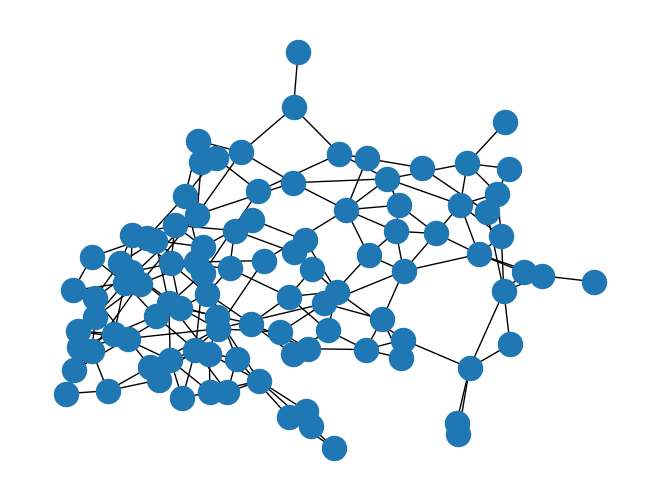

In [37]:
nx.draw(G)

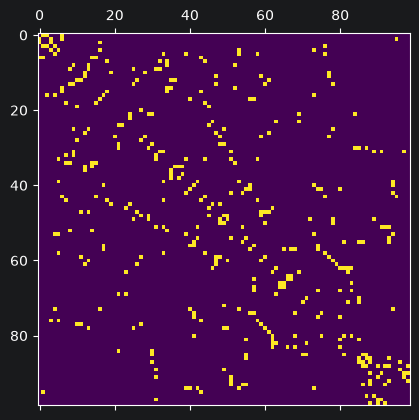

In [38]:
adj_matr = nx.adjacency_matrix(G).toarray()
plt.matshow(adj_matr)

In [39]:
MIN_EDGE_WEIGHT = 10
MAX_EDGE_WEIGHT = 50
weight_dist=stats.uniform(MIN_EDGE_WEIGHT,MAX_EDGE_WEIGHT)
for u,v in G.edges():
    G[u][v]['weight'] = weight_dist.rvs(1)[0]


In [40]:
edge_midpoints = np.zeros((N_EDGES, 2))
for i, (u, v) in enumerate(unique_edges):
    x_u, y_u = pos[u]
    x_v, y_v = pos[v]
    edge_midpoints[i] = [(x_u + x_v) / 2.0, (y_u + y_v) / 2.0]

# Calculate pairwise physical distances and normalize
distance_matrix = squareform(pdist(edge_midpoints, metric='euclidean'))
max_dist = np.max(distance_matrix)
norm_distance_matrix = distance_matrix / max_dist if max_dist > 0 else distance_matrix

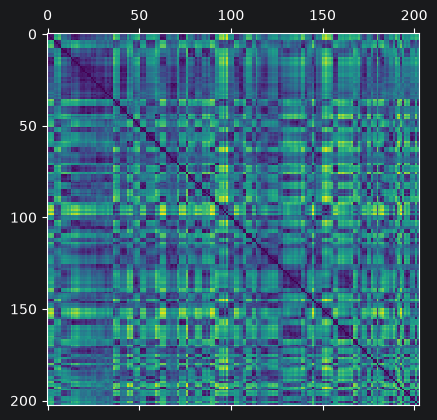

In [41]:
plt.matshow(norm_distance_matrix)

## Disaster Simulation

#### City Digital Twin

Each edge has an strength variable between 0-1.
Each edges strength is independent of each other --> might not also be

dayaniklilik < deprem

In [42]:
edge_strengths = stats.uniform(0,1).rvs(N_EDGES)
edge_strengths

array([0.39575879, 0.62573062, 0.67998578, 0.74893056, 0.91902693,
       0.15679989, 0.71617608, 0.86925966, 0.49957838, 0.30549986,
       0.37702784, 0.79133338, 0.88420985, 0.70784096, 0.93725933,
       0.91294343, 0.93478979, 0.91322095, 0.23817518, 0.31554345,
       0.80224111, 0.45747848, 0.47841679, 0.46375211, 0.10188885,
       0.43890752, 0.41427714, 0.5526645 , 0.22972179, 0.65516951,
       0.94549357, 0.50293897, 0.27776948, 0.65098742, 0.70015185,
       0.98012281, 0.29078446, 0.77579194, 0.68946981, 0.01626277,
       0.22650028, 0.06059441, 0.60638307, 0.36805108, 0.89776696,
       0.96271003, 0.81140692, 0.17988674, 0.43542965, 0.73816404,
       0.26409273, 0.07358418, 0.63061021, 0.19558951, 0.00835901,
       0.37306723, 0.69735487, 0.38440633, 0.05593251, 0.12176982,
       0.46387842, 0.8894577 , 0.61320379, 0.59773893, 0.11669002,
       0.43728048, 0.10160683, 0.18224599, 0.46870419, 0.00654957,
       0.46069716, 0.23786709, 0.8506792 , 0.59933149, 0.08729

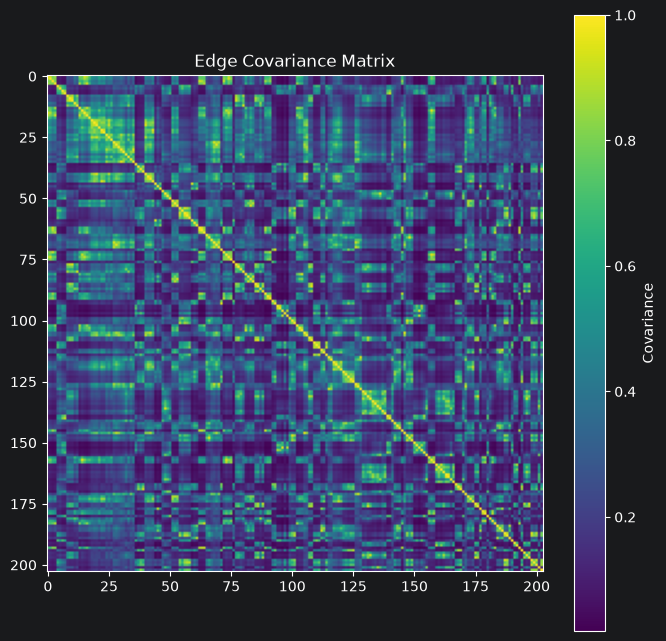

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# 2. Map each edge to a specific integer index (0 to N-1)
edge_to_idx = {edge: i for i, edge in enumerate(unique_edges)}
N = len(unique_edges)

# 3. Initialize an empty N x N NumPy array
cov_matrix = np.zeros((N, N))

# Parameters for exponential decay
gamma = 4.0    # Adjust this to control how quickly correlation drops off
sigma_sq = 1.0 # Variance scale

# 4. Populate the matrix
for i in range(N_EDGES):
    for j in range(N_EDGES):
        distance = norm_distance_matrix[i][j]

        # Exponential decay function
        cov_val = 1 * np.exp(-gamma * distance)

        # Covariance matrices are symmetric, so assign to both [i, j] and [j, i]
        cov_matrix[i, j] = cov_val
        cov_matrix[j, i] = cov_val

# 5. (Optional) Visualize the resulting covariance matrix
plt.figure(figsize=(8, 8))
plt.title("Edge Covariance Matrix")
plt.imshow(cov_matrix, cmap='viridis')
plt.colorbar(label='Covariance')
plt.show()

In [44]:
import numpy as np
from scipy.stats import multivariate_normal, norm

# Define N (number of edges)
# 1. Add a tiny jitter to the diagonal to prevent LinAlgError crashes
jitter = np.eye(N_EDGES) * 1e-8
safe_cov_matrix = cov_matrix + jitter

# 2. Initialize the Multivariate Normal distribution
# Mean is an array of zeros, matching the dimensions of the covariance matrix
edge_disaster_dist = multivariate_normal(mean=np.zeros(N), cov=safe_cov_matrix)

# 3. Sample ONE disaster scenario for the whole network (returns a 1D array of length N)
edges_disaster_samples = edge_disaster_dist.rvs()

# 4. Squash the correlated raw values into a [0, 1] probability/strength range
edge_disaster_strength = norm.cdf(edges_disaster_samples)

In [45]:
edge_collapse = (edge_strengths - edge_disaster_strength) <0
for i, (u, v) in enumerate(unique_edges):
    # State 1 if it collapsed (True), State 0 if safe (False)
    G[u][v]['state'] = 1 if edge_collapse[i] else 0
edge_collapse

array([ True,  True, False, False, False,  True, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True, False, False,  True,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False,  True,  True,  True,  True, False,  True, False,  True,
       False, False,  True,  True,  True, False, False, False, False,
        True,  True,  True,  True, False, False, False, False, False,
       False, False,  True,  True,  True,  True, False,  True, False,
       False,  True,  True,  True,  True, False,  True, False, False,
        True,  True, False, False,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
       False, False,

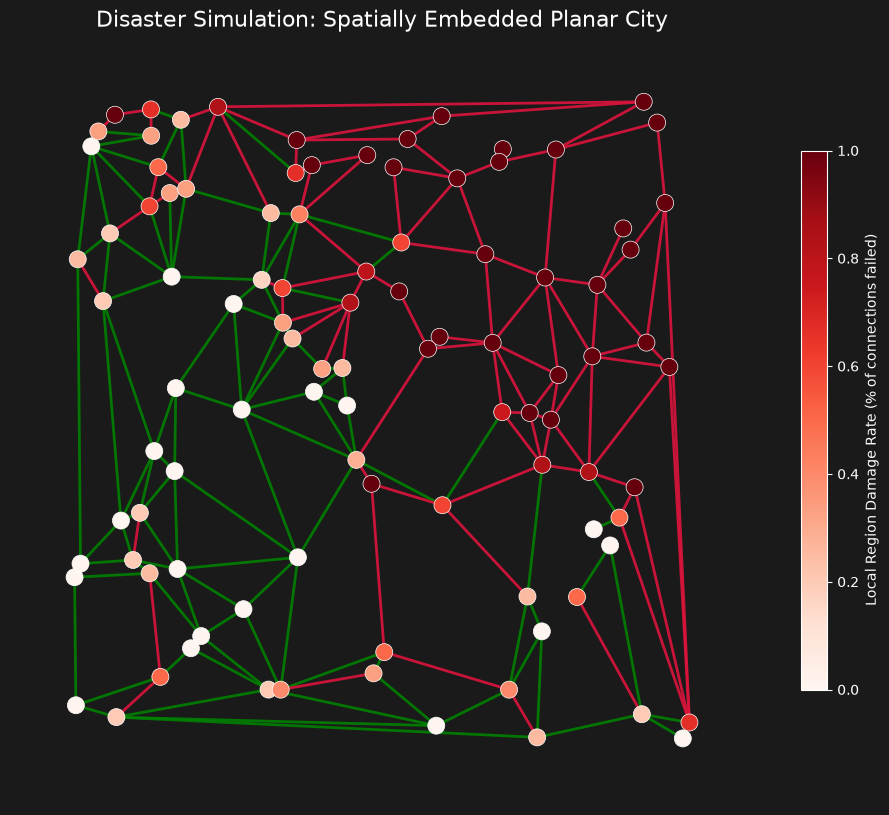

In [46]:
node_damage_ratios = []
for n in G.nodes():
    total_roads = G.degree(n)
    failed_roads = sum(1 for neighbor in G.neighbors(n) if G[n][neighbor].get('state', 0) == 1)
    damage_ratio = failed_roads / total_roads if total_roads > 0 else 0
    node_damage_ratios.append(damage_ratio)

failed_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('state', 0) == 1]
safe_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('state', 0) == 0]

plt.figure(figsize=(12, 10))
ax = plt.gca()
ax.set_facecolor('#1a1a1a')
plt.gcf().set_facecolor('#1a1a1a')

# Nodes: Heatmap based on damage percentage
nodes = nx.draw_networkx_nodes(
    G, pos,  # Using the actual physical coordinates
    node_size=150,
    node_color=node_damage_ratios,
    cmap=plt.cm.Reds,
    edgecolors="white",
    linewidths=0.5
)

# Ghosted safe infrastructure
nx.draw_networkx_edges(
    G, pos,
    edgelist=safe_edges,
    edge_color='green',
    width=2.0,
    alpha=0.9
)

# Highlighted damaged infrastructure
nx.draw_networkx_edges(
    G, pos,
    edgelist=failed_edges,
    edge_color='crimson',
    width=2.0,
    alpha=0.9
)

# Colorbar for regions
cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label('Local Region Damage Rate (% of connections failed)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

for spine in ax.spines.values():
    spine.set_edgecolor('#1a1a1a')

plt.title("Disaster Simulation: Spatially Embedded Planar City", color='white', fontsize=16)
plt.axis('off')
plt.show()